In [1]:
# Plot the Relative Risk for ozone with uncertainty

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from utils.utils import autosize_figure

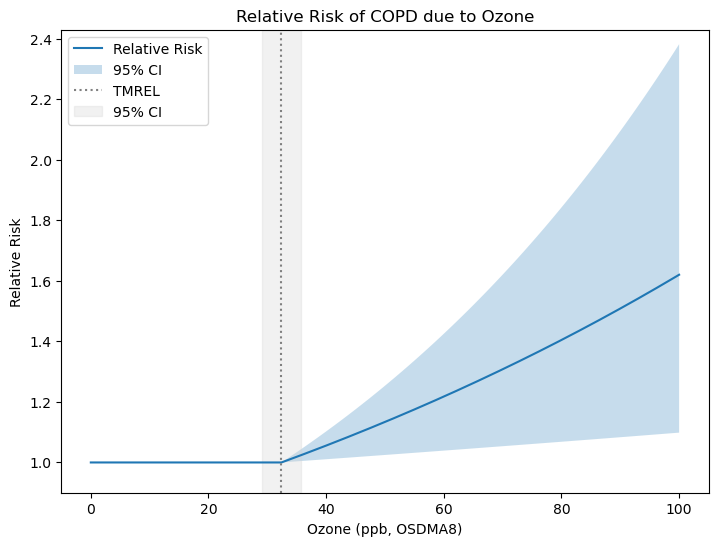

In [3]:
# Inputs
rr_per10 = 1.074  # [95% CI 1.014 – 1.137]
rr_low10 = 1.014
rr_high10 = 1.137
threshold = 32.4  # ppb where increase begins

# beta values
beta = np.log(rr_per10)/10
beta_low = np.log(rr_low10)/10
beta_high = np.log(rr_high10)/10

# Range for ozone
ozone = np.linspace(0, 100, 501)

# Piecewise linear RR equation is: RR = e^(beta*(Ozone-TMREL))
ozone_difference = np.clip(ozone - threshold, 0, None)  # 0 below threshold
rr = np.exp(beta * (ozone_difference))
rr_low = np.exp(beta_low * (ozone_difference))
rr_high = np.exp(beta_high * (ozone_difference))

# Plot
fig, ax = plt.subplots(figsize=autosize_figure(1, 1))
ax.plot(ozone, rr, label="Relative Risk")
ax.fill_between(ozone, rr_low, rr_high, alpha=0.25, label="95% CI")

# Threshold lines
ax.axvline(threshold, color="grey", linestyle=":", label="TMREL")
ax.axvspan(threshold-3.3, threshold+3.3, color="lightgrey", alpha=0.3, label="95% CI")

# Labels and title
ax.set_xlabel("Ozone (ppb, OSDMA8)")
ax.set_ylabel("Relative Risk")
ax.set_title("Relative Risk of COPD due to Ozone")
ax.legend()

# Optional: make the y-axis start near 1.0 for clarity
ymin = min(0.9, rr_low.min())
ax.set_ylim(ymin, rr_high.max()*1.02)

plt.show()
